# K-Nearest Neighbors on MNIST

**K-nearest neighbors (KNN)** predicts a label by finding similar labeled examples and taking a vote. Unlike a neural network, it does not learn weights during fitting.

MNIST, the **Modified National Institute of Standards and Technology** dataset, contains 28-by-28 grayscale images of handwritten digits. Run the cells in order with PyTorch, torchvision, NumPy, and Matplotlib installed. The first run downloads the data and needs an internet connection.


## Imports, Seed, and Device

PyTorch and torchvision load the images; NumPy performs the nearest-neighbor calculations. <code>Counter</code> counts votes. The PyTorch seed controls the shuffled training subset, but the later random image selection uses NumPy and is not seeded here.

Although the code prints a CUDA-or-CPU device, this KNN implementation converts the tensors to NumPy arrays and performs its distance calculations on the CPU.


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# set random seed for reproducibility
torch.manual_seed(42)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# -------------------------------
# 1. Load and Preprocess MNIST
# -------------------------------
# Define transformations: Convert to tensor & normalize


## Convert and Load Images

<code>ToTensor()</code> converts pixel intensities into floating-point values in [0, 1]. Normalizing with mean 0.5 and standard deviation 0.5 maps that range to [-1, 1]. The same transformation is used for training and test images.

The dataset is cached under <code>~/temp_data</code>. Training labels provide neighbors' votes; test labels are held aside for measuring accuracy.


In [ ]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# Load MNIST dataset
batch_size = 10000  # Load a large batch since KNN requires all data
train_dataset = torchvision.datasets.MNIST(root='~/temp_data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='~/temp_data', train=False, transform=transform, download=True)



## Select Batches and Flatten Images

The code takes only the **first batch** from each loader. With a batch size of 10,000, that means 10,000 shuffled training examples, not all 60,000 MNIST training images, and all 10,000 test images.

Flattening changes each image from shape <code>(1, 28, 28)</code> to a 784-element feature vector. Row <code>i</code> of the data remains paired with label <code>i</code>. The printed shapes in the saved run confirm these dimensions.


In [ ]:
# Convert dataset to DataLoader
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# Extract data from DataLoader
train_data, train_labels = next(iter(train_loader))
test_data, test_labels = next(iter(test_loader))

# Flatten images (28x28 → 784)
train_data = train_data.view(train_data.size(0), -1).numpy()
test_data = test_data.view(test_data.size(0), -1).numpy()

# Convert labels to numpy
train_labels = train_labels.numpy()
test_labels = test_labels.numpy()

print(f"Train data shape: {train_data.shape}, Train labels shape: {train_labels.shape}")
print(f"Test data shape: {test_data.shape}, Test labels shape: {test_labels.shape}")

# -------------------------------
# 2. Implement Custom KNN
# -------------------------------


## Store Examples and Predict

The class remains a single runnable cell. Its three methods have distinct jobs:

- `__init__` stores the chosen number of neighbors.
- <code>fit(X, y)</code> retains the examples and labels. There is no gradient descent or parameter training.
- <code>predict(X)</code> computes Euclidean distances to every stored example, sorts them, takes the nearest <code>k</code>, and returns the most frequent label.

Choose <code>k</code> between 1 and the number of stored examples. Voting ties follow the encounter order of labels in this implementation. Flattened pixel distance is a simple baseline; it does not explicitly understand shifted or rotated digits.


In [ ]:
class CustomKNN:
    def __init__(self, k=3):
        self.k = k
        self.train_data = None
        self.train_labels = None

    def fit(self, X, y):
        """Stores training data and labels"""
        self.train_data = X
        self.train_labels = y

    def predict(self, X):
        """Predict labels for given test data"""
        predictions = []
        for test_sample in X:
            # Compute distances (Euclidean)
            distances = np.linalg.norm(self.train_data - test_sample, axis=1)
            
            # Find k nearest neighbors
            k_indices = np.argsort(distances)[:self.k]
            k_nearest_labels = self.train_labels[k_indices]
            
            # Get most common label among neighbors
            most_common = Counter(k_nearest_labels).most_common(1)[0][0]
            predictions.append(most_common)
        
        return np.array(predictions)

# -------------------------------
# 3. Train & Evaluate the Model
# -------------------------------


## Fit and Evaluate

For each test image, the prediction uses only stored training labels. Accuracy is the fraction of predicted labels equal to the held-out test labels. The saved text below includes earlier device and shape messages as well as this result.

Prediction is the expensive step: 10,000 queries each compare against 10,000 vectors of length 784 and sort the resulting distances. For a quick trial, reduce the batch size and rerun the data-preparation cells.


In [ ]:
k = 3  # Set k
knn = CustomKNN(k)
print("\nTraining KNN model...")
knn.fit(train_data, train_labels)

print("\nEvaluating model...")
test_predictions = knn.predict(test_data)
accuracy = np.mean(test_predictions == test_labels)  # Accuracy calculation
print(f"KNN Classification Accuracy: {accuracy * 100:.2f}%")

# -------------------------------
# 4. Visualize Some Predictions
# -------------------------------


Using device: cpu
Train data shape: (10000, 784), Train labels shape: (10000,)
Test data shape: (10000, 784), Test labels shape: (10000,)

Training KNN model...

Evaluating model...
KNN Classification Accuracy: 95.02%


## Draw Predictions

The helper samples test indices, reshapes each flattened vector into a 28-by-28 image, and places the true and predicted labels above it. Green titles indicate correct predictions; red titles indicate errors. It reads the arrays produced by the preceding cells.


In [ ]:
def visualize_predictions(n=5):
    indices = np.random.choice(len(test_data), n, replace=False)
    
    plt.figure(figsize=(10, 5))
    for i, idx in enumerate(indices):
        image = test_data[idx].reshape(28, 28)
        true_label = test_labels[idx]
        predicted_label = test_predictions[idx]

        plt.subplot(1, n, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"True: {true_label}\nPred: {predicted_label}", color="green" if true_label == predicted_label else "red")
        plt.axis('off')
    
    plt.show()



## Inspect Five Examples

A handful of images helps explain individual predictions, but is not a substitute for accuracy over the full evaluated test set.


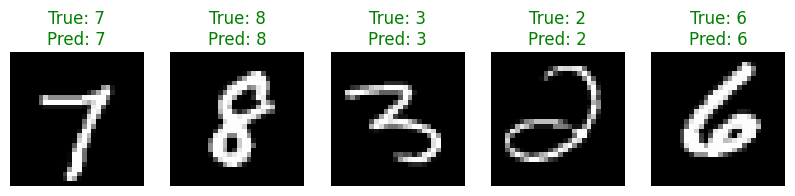

In [ ]:
visualize_predictions(5)

## Inspect a Larger Sample

This call chooses ten fresh random images. Ambiguous handwriting can reveal why pixel distance and a small neighbor vote sometimes disagree with the true label.


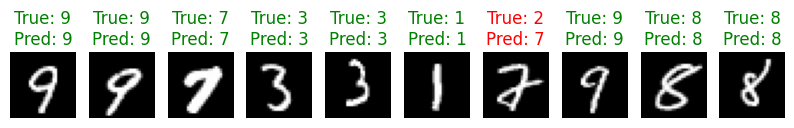

In [7]:
visualize_predictions(10)

## Questions to Explore

- Compare small and large values of <code>k</code>. How does the vote trade sensitivity to nearby examples against smoothing?
- Use a validation subset of training data to select <code>k</code>; keep the test set for final evaluation.
- How would doubling the number of stored examples affect prediction work and memory?

<details class="notebook-answers">
<summary>Answers and discussion</summary>

1. **Small k is local; large k smooths.** At `k = 1`, one nearby training example determines the prediction, making the classifier sensitive to noise and unusual examples. A larger vote is more stable but can mix nearby classes and miss fine distinctions. At the extreme of using every stored example, every query receives the same overall majority-label vote, subject to tie-breaking. Accuracy need not improve monotonically with k.
2. **Choose k without using the test answers.** Split the available training examples into a reference set and a validation set. Store only reference examples in `fit`, compare candidate k values on validation accuracy, and choose one. Then fit using the available training data and evaluate on the untouched test set. Repeatedly choosing k from test accuracy would make the reported test result optimistically biased.
3. **More stored examples increase both work and memory.** Holding feature dimension and the number of test queries fixed, doubling stored examples doubles the distance-computation work and stored feature/label memory. This implementation also fully sorts the distances for each query; its sorting cost grows as N log N, so that component increases a little more than twofold. The distance and sorting temporary arrays grow too.

</details>

**Takeaway:** KNN postpones most of its work until prediction. The representation, distance measure, and reference examples define what "similar" means.
